In [1]:
from OOP_so_far import ModuleProperties, CombiningModules, RunSSA
from sympy import *
import numpy as np
import time
import matplotlib.pyplot as plt

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1676: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


In [ ]:

# Module 1

SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["A1", "A2","A3","S","Na"]

num_internal_species = 3

# Module 2


SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["B1", "B2", "B3", "B4", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Module 3

# SM3 = Matrix([
#     [ 1, -1,  0,  0,  0,  0],  # EcNex
#     [-1,  1, -1,  1,  0,  0],  # Ec
#     [ 0,  0,  1, -1,  0,  0],  # EcNb
#     [ 0,  0,  0,  0, -1,  1],  # Ec*
#     [ 0,  0,  0,  0,  1, -1],  # Ec*Ne
#     [ 0,  0,  0,  0, -1,  0],  # Ne
#     [-1,  0,  0,  0,  0,  0],  # Nex
#     [ 0,  0, -1,  0,  0,  0],  # Nb
#     [ 0,  1,  0,  0,  0,  0],  # Pex
#     [ 0,  0,  0,  1,  0,  0],  # Pb  # col 4 entry uncertain
#     [ 0,  0,  0,  0,  0,  1],  # Pe
# ])

SM3=Matrix([
    [-1,1,-1,1,0,0],
    [1,-1,0,0,0,0],
    [0,0,1,-1,0,0],
    [0,0,0,0,-1,1],
    [0,0,0,0,1,-1],
    [-1,0,0,0,0,0],
    [0,0,-1,0,0,0],
    [0,0,0,0,-1,0],
    [0,1,0,0,0,0],
    [0,0,0,1,0,0],
    [0,0,0,0,0,1]
])

# species_names3 = ["C1", "C2", "C3", "C4", "C5", "Ne", "Nex", "Nb", "Pex", "Pb", "Pe"]
species_names3 = ["C1", "C2", "C3", "C4", "C5", "Nex","Nb","Ne","Pex","Pb","Pe"]
# Module 4

# SM4 = Matrix([
#     [ 1,  1, -1,  0,  1],  # Ed
#     [-1, -1,  1,  1,  0],  # EdS
#     [ 0,  1,  0, -1, -1],  # Ed*
#     [ 0,  0, -1, -1,  0],  # Nd
#     [ 1,  0,  0,  0,  0],  # S
# ])

# SM4 = Matrix([[-1,0,1,0,-1],
#             [0,-1,0,1,1],
#             [1,1,-1,-1,0],
#             [-1,-1,0,0,0],
#             [0,0,1,1,0]])

# display(SM4)

SM4 = Matrix([[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names4 = ["D1", "D2", "D3", "Nd", "S"] # swapped S and Nd


module1 = ModuleProperties(SM, 3, species_names)
display(module1.calculate_fundamental_resistance_matrix())

module2 = ModuleProperties(SM2, 4, species_names2)
display(module2.calculate_fundamental_resistance_matrix())

module3 = ModuleProperties(SM3, 5, species_names3)
display(module3.calculate_fundamental_resistance_matrix())

module4 = ModuleProperties(SM4, 3, species_names4)
display(module4.calculate_fundamental_resistance_matrix())

[r₁ + r₂]

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

⎡r₁ + r₂     0        0   ⎤
⎢                         ⎥
⎢   0     r₃ + r₄     0   ⎥
⎢                         ⎥
⎣   0        0     r₅ + r₆⎦

[r₁ + r₂]

In [ ]:

simulation_length = 1000.0

burn_in = 200.0

initial_counts = [350, 350, 350, 20, 22] # S = 20, Na = 22

rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])

SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)

initial_counts2 = [350, 350, 350, 350, 22, 12, 50, 50] # Na = 22, Nb = 12

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

SIM2 = RunSSA(module2, initial_counts2, rates2, simulation_length,burn_in)

# SIM2.run_SSA_and_plot_counts(True)
# Find good B.C and I.C for M3 and M4

initial_counts3 = [200, 200, 200, 200, 200, 20, 12, 20,20,20,20] # Nb =12
rates3 = 0.1*np.array([0.1,0.15,0.5,0.01,0.07,0.12,0.4,0.09,0.2,0.04,0.3,0.01])

SIM3 = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)



# SIM3.run_SSA_and_plot_counts(True)
# Find good B.C and I.C for M3 and M4



initial_counts4 = [350, 350, 350, 22, 20] #S = 20

# rates4 = 0.5*np.array([0.4,0.01,0.5,0.05,0.01,0.12,0.05,0.11,0.045,0.04])
# same as M1 rates
rates4 = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])
SIM4 = RunSSA(module4, initial_counts4, rates4, simulation_length, 300) # Burn in for M4 is 300 (see counts vs time plot)

# module4.fundamental_current_vector
# SIM4.run_SSA_and_plot_counts(True)

In [79]:
# Do a single run.

SIM1.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts[0]])],
        total_iterations=50, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM2.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts2[0]])],
        total_iterations=50, 
        covariance_reaction_indices=None,   
        verbose=True)

SIM3.run_IF_sweep(

        species_index=[0],
        count_values=[np.array([initial_counts3[0]])],
        total_iterations=50, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM4.run_IF_sweep(

        species_index=[0], 
        count_values=[np.array([initial_counts4[0]])],
        total_iterations=50, 
        covariance_reaction_indices=None,  
        verbose=True)

# FIND SEPERATE CMS
module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)
module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)
module3_conductances, _ = SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)
module4_conductances, _ = SIM4.compute_conductances(analytical_currents=None, analytical_forces=None)



Sweep 1/1  ([A1] = 350)
Total sweep time: 0.47 s
Sweep 1/1  ([B1] = 350)
Total sweep time: 3.80 s
Sweep 1/1  ([C1] = 200)
Total sweep time: 1.84 s
Sweep 1/1  ([D1] = 350)
Total sweep time: 0.41 s


In [5]:
display(SIM1.sweep_G_physical)
display(SIM2.sweep_G_physical)
display(SIM3.sweep_G_physical)
display(SIM4.sweep_G_physical)

⎡⎡3.04195767350533   -3.04195767350533⎤⎤
⎢⎢                                    ⎥⎥
⎣⎣-3.04195767350533  3.04195767350533 ⎦⎦

⎡⎡ 2.2655753157461   -2.2655753157461   1.05578955523506   -1.05578955523506⎤⎤
⎢⎢                                                                          ⎥⎥
⎢⎢-2.2655753157461    2.2655753157461   -1.05578955523506  1.05578955523506 ⎥⎥
⎢⎢                                                                          ⎥⎥
⎢⎢1.05578955523506   -1.05578955523506  10.3411611450692   -10.3411611450692⎥⎥
⎢⎢                                                                          ⎥⎥
⎣⎣-1.05578955523506  1.05578955523506   -10.3411611450692  10.3411611450692 ⎦⎦

⎡⎡2.70344873420246           0                  0          -2.70344873420246   ↪
⎢⎢                                                                             ↪
⎢⎢        0          3.38037478395809           0                  0           ↪
⎢⎢                                                                             ↪
⎢⎢        0                  0          2.09544849068966           0           ↪
⎢⎢                                                                             ↪
⎢⎢-2.70344873420246          0                  0          2.70344873420246    ↪
⎢⎢                                                                             ↪
⎢⎢        0          -3.38037478395809          0                  0           ↪
⎢⎢                                                                             ↪
⎣⎣        0                  0          -2.09544849068966          0           ↪

↪         0                  0        ⎤⎤
↪                                     ⎥⎥
↪ -3.38037478395809       

⎡⎡3.0161980418641   -3.0161980418641⎤⎤
⎢⎢                                  ⎥⎥
⎣⎣-3.0161980418641  3.0161980418641 ⎦⎦

# ONLY USING COMBININGMODULES: both methods of serial combination give the same! (to numerical error)

## test 1

In [80]:
# symbolic

M1_and_M2_sym1 = CombiningModules(module1,module2) # combine at Na

M1_M2_and_M3_sym1 = CombiningModules(M1_and_M2_sym1, module3) # combine at Nb

full_network_sym1 = CombiningModules(module4, M1_M2_and_M3_sym1) # combine at S

# final CM:

M1_M2_and_M3_sym1.fundamental_resistance_matrix # resistance is simpler to understand


pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 2
pi_2_3 shape: (4, 4), rank: 4
S1.pinv() shape: (1, 2)
S2.pinv() shape: (2, 4)
n1_l: 1, n2_r: 3, pi_rows: 1, pi_cols: 4

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4, 0, 0]])

PI_1_3:
Matrix([[1, 0]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1, 0], [0, 1]])
PI_2_3 rank: 2
PI_1_3 shape: (1, 2), rank: 1
PI_2_3 shape: (2, 2), rank: 2
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [

⎡r₁₀   r₁₃   r₁₄                  r₉    r₁₀   r₁₃   r₁₄   r₉                   ↪
⎢─── + ─── + ─── + r₄ + r₅ + r₆ + ──  - ─── - ─── - ─── - ──                 - ↪
⎢ 4     4     4                   4      4     4     4    4                    ↪
⎢                                                                              ↪
⎢        r₁₀   r₁₃   r₁₄   r₉          r₁₀   r₁₃   r₁₄   r₉                    ↪
⎢      - ─── - ─── - ─── - ──          ─── + ─── + ─── + ──                    ↪
⎢         4     4     4    4            4     4     4    4                     ↪
⎢                                                                              ↪
⎢                                                                  r₁₁   r₁₂   ↪
⎢                -r₅                            0             r₁ + ─── + ─── + ↪
⎢                                                                   4     4    ↪
⎢                                                                              ↪
⎢                           

In [81]:
# numerical

M1_and_M2_num1 = CombiningModules(module1,module2, module1_conductances, module2_conductances) # combine at Na
JN1_CM_num1 = M1_and_M2_num1.numerical_combined_fundamental_CMs

M1_M2_and_M3_num1 = CombiningModules(M1_and_M2_num1, module3, JN1_CM_num1, module3_conductances) # combine at Nb
JN2_CM_num1 = M1_M2_and_M3_num1.numerical_combined_fundamental_CMs

full_network_num1 = CombiningModules(module4, M1_M2_and_M3_num1, module4_conductances,JN2_CM_num1) # combine at S

# final CM:

M1_M2_and_M3_num1.numerical_combined_fundamental_CMs[0].inv()

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 2
pi_2_3 shape: (4, 4), rank: 4
S1.pinv() shape: (1, 2)
S2.pinv() shape: (2, 4)
n1_l: 1, n2_r: 3, pi_rows: 1, pi_cols: 4

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4, 0, 0]])

PI_1_3:
Matrix([[1, 0]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1, 0], [0, 1]])
PI_2_3 rank: 2
PI_1_3 shape: (1, 2), rank: 1
PI_2_3 shape: (2, 2), rank: 2
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [

⎡ 0.313820604148569    -0.212139456378471   -0.0473156655537105   5.2658455396 ↪
⎢                                                                              ↪
⎢-0.212139456378471    0.212139456378471    1.85552169439548e-17           0   ↪
⎢                                                                              ↪
⎢-0.0473156655537105  1.85552169439548e-17   0.863722170923779    -0.075888832 ↪
⎢                                                                              ↪
⎣         0                    0            -0.0758888320328964    0.075888832 ↪

↪ 7704e-19⎤
↪         ⎥
↪         ⎥
↪         ⎥
↪ 0328964 ⎥
↪         ⎥
↪ 0328964 ⎦

# test 2

In [82]:
# symbolic

M4_and_M1_sym2 = CombiningModules(module4, module1)

M2_and_M3_sym2 = CombiningModules(module2, module3)

full_network_sym2 = CombiningModules(M4_and_M1_sym2, M2_and_M3_sym2)

# final CM

full_network_sym2.fundamental_resistance_matrix # resistance is simpler to understand

pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])
pi_2_3:
Matrix([[1/2, -1/2], [0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (2, 1), rank: 1
S3 shape: (2, 1), rank: 1
pi shape: (1, 2)
pi_1_3 shape: (2, 2), rank: 2
pi_2_3 shape: (2, 2), rank: 2
S1.pinv() shape: (1, 2)
S2.pinv() shape: (1, 2)
n1_l: 1, n2_r: 1, pi_rows: 1, pi_cols: 2

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1], [1]])

pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4]])

PI_1_3:
Matrix([[1]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1]])
PI_2_3 rank: 1
PI_1_3 shape: (1, 1), rank: 1
PI_2_3 shape: (1, 1), rank: 1
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (4, 2), rank: 2
S2 shape: (6, 3), rank: 3
S3

⎡r₁₂   r₁₃   r₁₆   r₁₇                   r₁₂   r₁₃   r₁₆   r₁₇                 ↪
⎢─── + ─── + ─── + ─── + r₇ + r₈ + r₉  - ─── - ─── - ─── - ───                 ↪
⎢ 4     4     4     4                     4     4     4     4                  ↪
⎢                                                                              ↪
⎢        r₁₂   r₁₃   r₁₆   r₁₇          r₁₂   r₁₃   r₁₆   r₁₇                  ↪
⎢      - ─── - ─── - ─── - ───          ─── + ─── + ─── + ───                  ↪
⎢         4     4     4     4            4     4     4     4                   ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                -r₈                              0             r₁ + r₁₀ + r₁₁ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

In [83]:
# numerical

M4_and_M1_num2 = CombiningModules(module4,module1, module4_conductances, module1_conductances) # combine at S
JN1_CM_num2 = M4_and_M1_num2.numerical_combined_fundamental_CMs

M2_and_M3_num2 = CombiningModules(module2, module3, module2_conductances , module3_conductances) # combine at Nb
JN2_CM_num2 = M2_and_M3_num2.numerical_combined_fundamental_CMs

full_network_num2 = CombiningModules(M4_and_M1_num2, M2_and_M3_num2, JN1_CM_num2,JN2_CM_num2) # combine at Na

# final CM:

full_network_num2.numerical_combined_fundamental_CMs[0].inv()

pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])
pi_2_3:
Matrix([[1/2, -1/2], [0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (2, 1), rank: 1
S3 shape: (2, 1), rank: 1
pi shape: (1, 2)
pi_1_3 shape: (2, 2), rank: 2
pi_2_3 shape: (2, 2), rank: 2
S1.pinv() shape: (1, 2)
S2.pinv() shape: (1, 2)
n1_l: 1, n2_r: 1, pi_rows: 1, pi_cols: 2

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1], [1]])

pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4]])

PI_1_3:
Matrix([[1]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1]])
PI_2_3 rank: 1
PI_1_3 shape: (1, 1), rank: 1
PI_2_3 shape: (1, 1), rank: 1
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (4, 2), rank: 2
S2 shape: (6, 3), rank: 3
S3

⎡  0.313820604148569    -0.212139456378471  -0.0473156655537105  5.26584553967 ↪
⎢                                                                              ↪
⎢ -0.212139456378471    0.212139456378471            0                    0    ↪
⎢                                                                              ↪
⎢ -0.0473156655537105           0            1.19197389149007    -0.0758888320 ↪
⎢                                                                              ↪
⎣-5.26584553967704e-19          0           -0.0758888320328964   0.0758888320 ↪

↪ 704e-19⎤
↪        ⎥
↪        ⎥
↪        ⎥
↪ 328964 ⎥
↪        ⎥
↪ 328964 ⎦

# DIRECT SIMULATION: using M4:M1 and M2:M3

In [84]:
# build full network symbolically
 
M4_and_M1_direct = CombiningModules(module4, module1) # Connect at S
M4_and_M1_combined_counts, M4_and_M1_combined_rates  = M4_and_M1_direct.build_combined_initial_counts_and_rates(initial_counts4, initial_counts, rates4, rates)


M2_and_M3_direct = CombiningModules(module2, module3) # connect at Nb
M2_and_M3_combined_counts, M2_and_M3_combined_rates = M2_and_M3_direct.build_combined_initial_counts_and_rates(initial_counts2, initial_counts3, rates2, rates3)


final_network_direct = CombiningModules(M4_and_M1_direct,M2_and_M3_direct) # connect at Na
final_network_direct_combined_counts, final_network_direct_combined_rates = final_network_direct.build_combined_initial_counts_and_rates(\
    M4_and_M1_combined_counts, M2_and_M3_combined_counts, M4_and_M1_combined_rates, M2_and_M3_combined_rates)


pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])
pi_2_3:
Matrix([[1/2, -1/2], [0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (2, 1), rank: 1
S3 shape: (2, 1), rank: 1
pi shape: (1, 2)
pi_1_3 shape: (2, 2), rank: 2
pi_2_3 shape: (2, 2), rank: 2
S1.pinv() shape: (1, 2)
S2.pinv() shape: (1, 2)
n1_l: 1, n2_r: 1, pi_rows: 1, pi_cols: 2

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1], [1]])

pi_1_3:
Matrix([[1, 0], [-1/2, 1/2]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4]])

PI_1_3:
Matrix([[1]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1]])
PI_2_3 rank: 1
PI_1_3 shape: (1, 1), rank: 1
PI_2_3 shape: (1, 1), rank: 1

=== Overlapping species detected ===
  ['S']
These species appear in both modules and are now internal.

  Species 'S':
    Left  module value: 20
    Right module value: 20

=== Combined initial counts ===
  [0] D1           : 350
  [1] D2           : 350
  [2] D3           : 350
  [3] S            : 20.0 ← user entered
  [4] A1           : 350
  [5] A2           : 350
  [6] A3   

## with making the ModProps variable

In [11]:
final_network_ModProps = ModuleProperties(final_network_direct.stoich_matrix, final_network_direct.num_internal_species, final_network_direct.species_names)

SIM_direct_ModProps = RunSSA(final_network_ModProps, final_network_direct_combined_counts, final_network_direct_combined_rates, 1000, 400)

SIM_direct_ModProps.run_IF_sweep(species_index=[0], 
        count_values=[np.array([final_network_direct_combined_counts[0]])],
        total_iterations=10, 
        covariance_reaction_indices=None,  
        verbose=True)


modprops_CM = SIM_direct_ModProps.compute_conductances(analytical_currents=None, analytical_forces=None)[0]

Sweep 1/1  ([D1] = 350)
Total sweep time: 6.86 s


## without making the ModProps variable

In [19]:
SIM_direct = RunSSA(final_network_direct, final_network_direct_combined_counts, final_network_direct_combined_rates, 2000, 1250)

SIM_direct.run_IF_sweep(species_index=[0], 
        count_values=[np.array([final_network_direct_combined_counts[0]])],
        total_iterations=5, 
        covariance_reaction_indices=None, 
        verbose=True)


combmods_CM = SIM_direct.compute_conductances2(analytical_currents=None, analytical_forces=None)[0]


Sweep 1/1  ([D1] = 350)
Total sweep time: 6.46 s


In [76]:
final_network_direct.fundamental_resistance_matrix

⎡r₁₂   r₁₃   r₁₆   r₁₇                   r₁₂   r₁₃   r₁₆   r₁₇                 ↪
⎢─── + ─── + ─── + ─── + r₇ + r₈ + r₉  - ─── - ─── - ─── - ───                 ↪
⎢ 4     4     4     4                     4     4     4     4                  ↪
⎢                                                                              ↪
⎢        r₁₂   r₁₃   r₁₆   r₁₇          r₁₂   r₁₃   r₁₆   r₁₇                  ↪
⎢      - ─── - ─── - ─── - ───          ─── + ─── + ─── + ───                  ↪
⎢         4     4     4     4            4     4     4     4                   ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                -r₈                              0             r₁ + r₁₀ + r₁₁ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

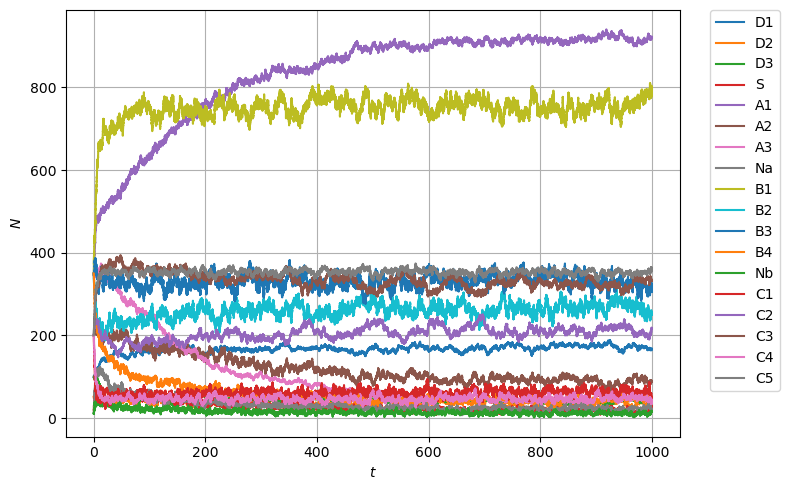

In [160]:
SIM_direct = RunSSA(final_network_direct, final_network_direct_combined_counts, final_network_direct_combined_rates, 1000, 600)
SIM_direct.run_SSA_and_plot_counts(True)

# Compare evals

Combined eigenvalues:  [ 1.13762085  2.09465906 14.57917469 22.99505789]
Direct   eigenvalues:  [ 0.92172591  2.09597402  2.70285139 10.00529746]
Max absolute diff:     12.989760436264842
Max relative diff:     4.3939978962796244
Matrices match:        False


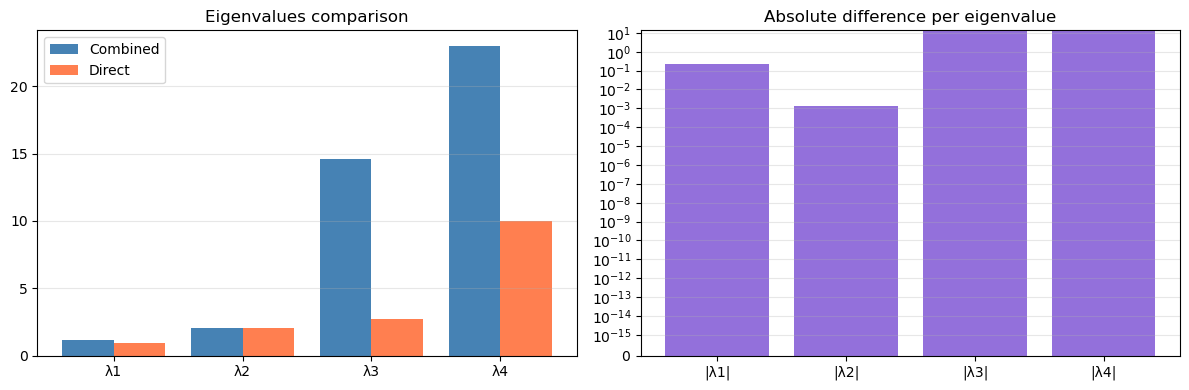

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def clean_matrix(mat, threshold=1e-14):
    """Replace near-zero, NaN, and Inf values."""
    mat = np.array(mat, dtype=complex)
    mat = np.where(np.isnan(mat), 0, mat)
    mat = np.where(np.isinf(mat), 0, mat)
    mat = np.where(np.abs(mat) < threshold, 0, mat)
    return mat

def get_eigenvalues(mat, threshold=1e-14):
    mat = clean_matrix(mat, threshold)
    eigs = np.linalg.eigvals(mat)
    eigs = np.where(np.abs(eigs.real) < threshold, 0, eigs.real)
    return np.sort(eigs.real)

# --- Your matrices here ---
comb_matrix  = np.array(new_step2_RM.inv().tolist(), dtype=float)
direct_matrix = np.array(step_2_sim_via_ModProps[0].tolist(), dtype=float)

comb_evals  = get_eigenvalues(comb_matrix)
direct_evals = get_eigenvalues(direct_matrix)

print("Combined eigenvalues: ", comb_evals)
print("Direct   eigenvalues: ", direct_evals)
print("Max absolute diff:    ", np.max(np.abs(comb_evals - direct_evals)))
print("Max relative diff:    ", np.max(np.abs(comb_evals - direct_evals) / (np.abs(direct_evals) + 1e-30)))
print("Matrices match:       ", np.allclose(comb_evals, direct_evals, atol=1e-10))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(comb_evals))
axes[0].bar(x - 0.2, comb_evals,  0.4, label='Combined',  color='steelblue')
axes[0].bar(x + 0.2, direct_evals, 0.4, label='Direct',    color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'λ{i+1}' for i in x])
axes[0].set_title('Eigenvalues comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

diff = np.abs(comb_evals - direct_evals)
axes[1].bar(x, diff, color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'|λ{i+1}|' for i in x])
axes[1].set_title('Absolute difference per eigenvalue')
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [161]:
def get_steady_state_values(sim, species_of_interest):
    """
    Extract steady state values (final timepoint) from a RunSSA object.
    
    Parameters
    ----------
    sim : RunSSA
        A RunSSA object after calling run_SSA_and_plot_counts().
    species_of_interest : list of str
        Species names to extract, e.g. ['S', 'Na', 'Nb'].
    
    Returns
    -------
    dict : {species_name: final_count}
    """
    if not hasattr(sim, 'final_pops'):
        raise RuntimeError("No final_pops found. Call sim.run_SSA_and_plot_counts() first.")
    
    name_to_final = dict(zip(sim.species_names, sim.final_pops))
    
    results = {}
    for species in species_of_interest:
        if species in name_to_final:
            results[species] = name_to_final[species]
        else:
            print(f"Warning: '{species}' not found in simulation. "
                  f"Available species: {sim.species_names}")
    
    return results


# --- Usage ---
SIM_direct.run_SSA_and_plot_counts(store_trajectories=False)

repeats = 100
SS_S = []
SS_Na = []
SS_Nb = []

for i in range(repeats):
    print(f'Repeat: {i+1}')

    SIM_direct.run_SSA_and_plot_counts(store_trajectories=False)

    steady_state = get_steady_state_values(SIM_direct, ['S', 'Na', 'Nb'])
    v = steady_state.values()
    vals=[]
    for val in v:
        vals.append(val)
    
    SS_S.append(vals[0])
    SS_Na.append(vals[1])
    SS_Nb.append(vals[2])
    


Repeat: 1
Repeat: 2
Repeat: 3
Repeat: 4
Repeat: 5
Repeat: 6
Repeat: 7
Repeat: 8
Repeat: 9
Repeat: 10
Repeat: 11
Repeat: 12
Repeat: 13
Repeat: 14
Repeat: 15
Repeat: 16
Repeat: 17
Repeat: 18
Repeat: 19
Repeat: 20
Repeat: 21
Repeat: 22
Repeat: 23
Repeat: 24
Repeat: 25
Repeat: 26
Repeat: 27
Repeat: 28
Repeat: 29
Repeat: 30
Repeat: 31
Repeat: 32
Repeat: 33
Repeat: 34
Repeat: 35
Repeat: 36
Repeat: 37
Repeat: 38
Repeat: 39
Repeat: 40
Repeat: 41
Repeat: 42
Repeat: 43
Repeat: 44
Repeat: 45
Repeat: 46
Repeat: 47
Repeat: 48
Repeat: 49
Repeat: 50
Repeat: 51
Repeat: 52
Repeat: 53
Repeat: 54
Repeat: 55
Repeat: 56
Repeat: 57
Repeat: 58
Repeat: 59
Repeat: 60
Repeat: 61
Repeat: 62
Repeat: 63
Repeat: 64
Repeat: 65
Repeat: 66
Repeat: 67
Repeat: 68
Repeat: 69
Repeat: 70
Repeat: 71
Repeat: 72
Repeat: 73
Repeat: 74
Repeat: 75
Repeat: 76
Repeat: 77
Repeat: 78
Repeat: 79
Repeat: 80
Repeat: 81
Repeat: 82
Repeat: 83
Repeat: 84
Repeat: 85
Repeat: 86
Repeat: 87
Repeat: 88
Repeat: 89
Repeat: 90
Repeat: 91
Repeat: 

In [162]:
print(np.mean(SS_S))
print(np.mean(SS_Na))
print(np.mean(SS_Nb))

19.75
22.28
12.05


In [182]:
# Check selection matrices used in each approach

# Analytical (from CombiningModules)
print("Combined selection matrix (analytical):")
print(full_network_num2.selection_matrix)

# Direct (from full network simulation)
print("\nDirect module selection matrix:")
print(final_network_direct.selection_matrix)

# Check if they span the same space
S_analytical = full_network_num2.selection_matrix
S_direct = final_network_direct.selection_matrix

# If same space: columns of S_direct should be linear combinations of S_analytical
# Test: does augmented matrix have same rank as S_analytical?
augmented = S_analytical.row_join(S_direct)
print("\nS_analytical rank:", S_analytical.rank())
print("S_direct rank:", S_direct.rank())
print("Augmented rank:", augmented.rank())
# If augmented rank == S_analytical rank → same subspace → just different basis

Combined selection matrix (analytical):
Matrix([[-1, 0, 0, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, -1], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

Direct module selection matrix:
Matrix([[-1, 0, 0, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, -1], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

S_analytical rank: 4
S_direct rank: 4
Augmented rank: 4


In [49]:
# COMBINING ALL 4 MODULES (pre-simulated)

# STEP 1
# numerical
step1 = CombiningModules(module1,module2, module1_conductances, module2_conductances) # combine at Na
step1_numerical_RM = step1.numerical_combined_fundamental_CMs[0].inv()
# sym
step1_sym = CombiningModules(module1, module2)
step1_sym_RM = step1_sym.fundamental_resistance_matrix

print("Numerical RM after Step 1:")
display(step1_numerical_RM)
print("Symbolic RM after Step 1:")
display(step1_sym_RM)
print(" ")

#STEP 2
# numerical
step2 = CombiningModules(step1, module3, [step1_numerical_RM.inv()], module3_conductances) # combine at Nb
step2_numerical_RM = step2.numerical_combined_fundamental_CMs[0].inv()
# sym
step2_sym = CombiningModules(step1_sym, module3)
step2_sym_RM = step2_sym.fundamental_resistance_matrix

print("Numerical RM after Step 2:")
display(step2_numerical_RM)
print("Symbolic RM after Step 2:")
display(step2_sym_RM)
print(" ")


# STEP 3
# numerical
step3 = CombiningModules(module4, step2, module4_conductances,[step2_numerical_RM.inv()]) # combine at S
step3_numerical_RM = step3.numerical_combined_fundamental_CMs[0].inv()
# sym
step3_sym = CombiningModules(module4, step2_sym)
step3_sym_RM = step3_sym.fundamental_resistance_matrix

print("Numerical RM after Step 3:")
display(step3_numerical_RM)
print("Symbolic RM after Step 3:")
display(step3_sym_RM)
print(" ")

# COMPARE TO DIRECT RM
step3_direct_module_variable = ModuleProperties(step3_sym.stoich_matrix, step3_sym.num_internal_species, step3_sym.species_names)

print("Via ModProps the full network RM:")
display(step3_direct_module_variable.calculate_fundamental_resistance_matrix()) # different!


# Check selection matrices used in each approach

# Analytical (from CombiningModules)
print("Combined selection matrix (analytical):")
display(step3.selection_matrix)

# Direct (from full network simulation)
print("\nDirect module selection matrix:")
display(step3_direct_module_variable.selection_matrix)

# Run direct simulation

final_network_ModProps = ModuleProperties(final_network_direct.stoich_matrix, final_network_direct.num_internal_species, final_network_direct.species_names)

SIM_direct_ModProps = RunSSA(final_network_ModProps, final_network_direct_combined_counts, final_network_direct_combined_rates, 1000, 400)

SIM_direct_ModProps.run_IF_sweep(species_index=[0], 
        count_values=[np.array([final_network_direct_combined_counts[0]])],
        total_iterations=10, 
        covariance_reaction_indices=None,  
        verbose=True)


modprops_CM = SIM_direct_ModProps.compute_conductances(analytical_currents=None, analytical_forces=None)[0]







pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 2
pi_2_3 shape: (4, 4), rank: 4
S1.pinv() shape: (1, 2)
S2.pinv() shape: (2, 4)
n1_l: 1, n2_r: 3, pi_rows: 1, pi_cols: 4

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4, 0, 0]])

PI_1_3:
Matrix([[1, 0]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1, 0], [0, 1]])
PI_2_3 rank: 2
PI_1_3 shape: (1, 2), rank: 1
PI_2_3 shape: (2, 2), rank: 2
pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 

⎡0.792017176374185   -0.047320339111092⎤
⎢                                      ⎥
⎣-0.047320339111092  0.101666382982147 ⎦

Symbolic RM after Step 1:


⎡r₁ + r₂ + r₅ + r₇ + r₈      -r₅     ⎤
⎢                                    ⎥
⎣         -r₅            r₄ + r₅ + r₆⎦

 
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (4, 2), rank: 2
S2 shape: (6, 3), rank: 3
S3 shape: (8, 4), rank: 4
pi shape: (1, 8)
pi_1_3 shape: (4, 8), rank: 4
pi_2_3 shape: (6, 8), rank: 6
S1.pinv() shape: (2, 4)
S2.pinv() shape: (3, 6)
n1_l: 3, n2_r: 5, pi_rows: 1, pi_cols: 8

S1:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

S3:
Matrix([[0, 0, -1, 0], [-1, 0, 0, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, 0, -1], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 0, 0, 0, 0, 0, 1/4, 0], [0, -1/2, 1/2, 0, 0, 0, 0, 0]])

PI_1_3:
Matrix([[0, 0, 1,

...

Combined selection matrix (analytical):


⎡0   0   -1  0 ⎤
⎢              ⎥
⎢-1  0   0   0 ⎥
⎢              ⎥
⎢1   0   0   0 ⎥
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢0   1   0   0 ⎥
⎢              ⎥
⎢0   0   1   0 ⎥
⎢              ⎥
⎣0   0   0   1 ⎦


Direct module selection matrix:


⎡0   0   -1  0 ⎤
⎢              ⎥
⎢-1  0   0   0 ⎥
⎢              ⎥
⎢1   0   0   0 ⎥
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢0   1   0   0 ⎥
⎢              ⎥
⎢0   0   1   0 ⎥
⎢              ⎥
⎣0   0   0   1 ⎦

Sweep 1/1  ([D1] = 350)
Total sweep time: 7.95 s


In [6]:
step3_direct_module_variable.cons_laws

⎡1   1   1  0  0   0   0  0  0   0   0   0  0  0   0   0  0   0  0  0  0  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  1   1   1  0  0   0   0   0  0  0   0   0  0   0  0  0  0  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  0   0   0  0  1   1   1   1  0  0   0   0  0   0  0  0  0  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  0   0   0  0  0   0   0   0  0  1   1   1  0   0  0  0  0  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  0   0   0  0  0   0   0   0  0  0   0   0  1   1  0  0  0  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  0   0   0  0  -1  0   0   0  0  0   0   0  0   0  0  1  1  0  0 ↪
⎢                                                                              ↪
⎢0   0   0  0  0   0   0  0 

In [7]:
step3_direct_module_variable.chemostat_cons_laws

⎡0  1  1  0  0  0  0  0⎤
⎢                      ⎥
⎢0  0  0  1  0  1  0  0⎥
⎢                      ⎥
⎢1  0  0  0  0  0  1  0⎥
⎢                      ⎥
⎣0  0  0  0  1  0  0  1⎦

In [15]:
print(step3_direct_module_variable.species_names)

['D1', 'D2', 'D3', 'S', 'A1', 'A2', 'A3', 'Na', 'B1', 'B2', 'B3', 'B4', 'Nb', 'C1', 'C2', 'C3', 'C4', 'C5', 'Nd', 'F', 'W', 'Nex', 'Ne', 'Pex', 'Pb', 'Pe']


In [8]:
step3_sym.conservation_laws_chemostat

⎡0  1  1  0  0  0  0  0⎤
⎢                      ⎥
⎢0  0  0  1  0  1  0  0⎥
⎢                      ⎥
⎢1  0  0  0  0  0  1  0⎥
⎢                      ⎥
⎣0  0  0  0  1  0  0  1⎦

In [14]:
print(step3_sym.species_names)

['D1', 'D2', 'D3', 'S', 'A1', 'A2', 'A3', 'Na', 'B1', 'B2', 'B3', 'B4', 'Nb', 'C1', 'C2', 'C3', 'C4', 'C5', 'Nd', 'F', 'W', 'Nex', 'Ne', 'Pex', 'Pb', 'Pe']


In [10]:
step3_direct_module_variable.calculate_fundamental_resistance_matrix() # different!

⎡r₇ + r₈ + r₉      0                           -r₈                             ↪
⎢                                                                              ↪
⎢     0        r₁₂ + r₁₃                        0                              ↪
⎢                                                                              ↪
⎢    -r₈           0      r₁ + r₁₀ + r₁₁ + r₁₄ + r₁₅ + r₂ + r₄ + r₅ + r₈       ↪
⎢                                                                              ↪
⎣     0            0                            0                         r₁₆  ↪

↪ 0    ⎤
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ + r₁₇⎦

In [13]:
step3_numerical_RM_np = np.array(step3_numerical_RM.inv().tolist(), dtype=float)
direct_RM_np          = np.array(modprops_CM[0].tolist(), dtype=float)

eigs_comb = np.sort(np.linalg.eigvals(step3_numerical_RM_np).real)
eigs_dir  = np.sort(np.linalg.eigvals(direct_RM_np).real)

print("Eigenvalues (modular):", eigs_comb)
print("Eigenvalues (direct): ", eigs_dir)
print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=0.05))

Eigenvalues (modular): [ 0.82950337  2.088008   14.18101918 22.75910808]
Eigenvalues (direct):  [0.75719244 2.10803311 2.64363298 9.84840718]
Match: False


In [17]:
# Rerun all combinations with the fix
step1_sym = CombiningModules(module1, module2)
step2_sym = CombiningModules(step1_sym, module3)
step3_sym = CombiningModules(module4, step2_sym)

# Check symbolic difference
diff = simplify(step3_sym.fundamental_resistance_matrix - 
                      step3_direct_module_variable.fundamental_resistance_matrix)

print("Symbolic difference:")
display(diff)

# Check symbols
print("\nModular symbols:", step3_sym.fundamental_resistance_matrix.free_symbols)
print("Direct symbols: ", step3_direct_module_variable.fundamental_resistance_matrix.free_symbols)

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 2
pi_2_3 shape: (4, 4), rank: 4
S1.pinv() shape: (1, 2)
S2.pinv() shape: (2, 4)
n1_l: 1, n2_r: 3, pi_rows: 1, pi_cols: 4

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4, 0, 0]])

PI_1_3:
Matrix([[1, 0]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1, 0], [0, 1]])
PI_2_3 rank: 2
PI_1_3 shape: (1, 2), rank: 1
PI_2_3 shape: (2, 2), rank: 2
pi_1_3:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
pi_2_3:
Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [

⎡ r₁₂   r₁₃   r₁₆   r₁₇       r₁₂   r₁₃   r₁₆   r₁₇                            ↪
⎢ ─── + ─── + ─── + ───     - ─── - ─── - ─── - ───           0                ↪
⎢  4     4     4     4         4     4     4     4                             ↪
⎢                                                                              ↪
⎢  r₁₂   r₁₃   r₁₆   r₁₇    3⋅r₁₂   3⋅r₁₃   r₁₆   r₁₇                          ↪
⎢- ─── - ─── - ─── - ───  - ───── - ───── + ─── + ───         0                ↪
⎢   4     4     4     4       4       4      4     4                           ↪
⎢                                                                              ↪
⎢                                                        3⋅r₁₄   3⋅r₁₅         ↪
⎢           0                          0               - ───── - ─────       - ↪
⎢                                                          4       4           ↪
⎢                                                                              ↪
⎢                           


Modular symbols: {r8, r10, r14, r1, r12, r16, r7, r4, r17, r11, r13, r15, r2, r9, r5}
Direct symbols:  {r11, r10, r8, r13, r15, r14, r1, r12, r16, r7, r2, r5, r4, r9, r17}


In [22]:
# Check each step individually against direct derivation

# Step 1: M1+M2 via Na
step1_direct = ModuleProperties(step1_sym.stoich_matrix, 
                                 step1_sym.num_internal_species, 
                                 step1_sym.species_names)

diff1 = simplify(step1_sym.fundamental_resistance_matrix - 
                        step1_direct.calculate_fundamental_resistance_matrix())
print("Step 1 symbolic difference:")
display(diff1)
print("Step 1 symbols modular:", step1_sym.fundamental_resistance_matrix.free_symbols)
print("Step 1 symbols direct: ", step1_direct.fundamental_resistance_matrix.free_symbols)

# Step 2: step1+M3 via Nb
step2_direct = ModuleProperties(step2_sym.stoich_matrix,
                                 step2_sym.num_internal_species,
                                 step2_sym.species_names)

diff2 = simplify(step2_sym.fundamental_resistance_matrix - 
                        step2_direct.calculate_fundamental_resistance_matrix())
print("\nStep 2 symbolic difference:")
display(diff2)
print("Step 2 symbols modular:", step2_sym.fundamental_resistance_matrix.free_symbols)
print("Step 2 symbols direct: ", step2_direct.fundamental_resistance_matrix.free_symbols)

# Step 3: M4+step2 via S
step3_direct = ModuleProperties(step3_sym.stoich_matrix,
                                 step3_sym.num_internal_species,
                                 step3_sym.species_names)

diff3 = simplify(step3_sym.fundamental_resistance_matrix - 
                        step3_direct.calculate_fundamental_resistance_matrix())
print("\nStep 3 symbolic difference:")

display(diff3)
print("Step 3 symbols modular:", step3_sym.fundamental_resistance_matrix.free_symbols)
print("Step 3 symbols direct: ", step3_direct.fundamental_resistance_matrix.free_symbols)

Step 1 symbolic difference:


⎡0  0⎤
⎢    ⎥
⎣0  0⎦

Step 1 symbols modular: {r8, r1, r6, r7, r5, r2, r4}
Step 1 symbols direct:  {r8, r1, r6, r7, r5, r2, r4}

Step 2 symbolic difference:


⎡ r₁₀   r₁₃   r₁₄   r₉       r₁₀   r₁₃   r₁₄   r₉                              ↪
⎢ ─── + ─── + ─── + ──     - ─── - ─── - ─── - ──           0                  ↪
⎢  4     4     4    4         4     4     4    4                               ↪
⎢                                                                              ↪
⎢  r₁₀   r₁₃   r₁₄   r₉    3⋅r₁₀   r₁₃   r₁₄   3⋅r₉                            ↪
⎢- ─── - ─── - ─── - ──  - ───── + ─── + ─── - ────         0                  ↪
⎢   4     4     4    4       4      4     4     4                              ↪
⎢                                                                              ↪
⎢                                                      3⋅r₁₁   3⋅r₁₂         r ↪
⎢          0                         0               - ───── - ─────       - ─ ↪
⎢                                                        4       4             ↪
⎢                                                                              ↪
⎢                           

Step 2 symbols modular: {r11, r10, r8, r13, r14, r1, r6, r12, r7, r5, r9, r2, r4}
Step 2 symbols direct:  {r11, r8, r10, r13, r14, r1, r6, r12, r7, r5, r2, r4, r9}

Step 3 symbolic difference:


⎡ r₁₂   r₁₃   r₁₆   r₁₇       r₁₂   r₁₃   r₁₆   r₁₇                            ↪
⎢ ─── + ─── + ─── + ───     - ─── - ─── - ─── - ───           0                ↪
⎢  4     4     4     4         4     4     4     4                             ↪
⎢                                                                              ↪
⎢  r₁₂   r₁₃   r₁₆   r₁₇    3⋅r₁₂   3⋅r₁₃   r₁₆   r₁₇                          ↪
⎢- ─── - ─── - ─── - ───  - ───── - ───── + ─── + ───         0                ↪
⎢   4     4     4     4       4       4      4     4                           ↪
⎢                                                                              ↪
⎢                                                        3⋅r₁₄   3⋅r₁₅         ↪
⎢           0                          0               - ───── - ─────       - ↪
⎢                                                          4       4           ↪
⎢                                                                              ↪
⎢                           

Step 3 symbols modular: {r8, r10, r14, r1, r12, r16, r7, r4, r17, r11, r13, r15, r2, r9, r5}
Step 3 symbols direct:  {r11, r10, r8, r13, r15, r14, r1, r12, r16, r7, r2, r5, r4, r9, r17}


In [55]:
# Manually run step 2 internals to check ordering consistency

left_mod  = step1_sym
right_mod = module3

# What ordering does S1 expect?
print("step1 chemostat_species_names:", left_mod.chemostat_species_names)
print("step1 selection matrix S1:")
display(left_mod.selection_matrix)
print("step1 conservation laws:")
display(left_mod.conservation_laws_chemostat)

# What is the physical current ordering step1 actually produces?
print("\nstep1 physical currents:")
display(left_mod.physical_currents)

# What are the interface species at step 2?
left_ext_names_list = left_mod.chemostat_species_names
print("\nleft_ext_names_list:", left_ext_names_list)

interface_names = [n for n in left_ext_names_list 
                   if n in [right_mod.species_labels[j] 
                            for j in range(right_mod.num_internal_species, 
                                          right_mod.num_species)]]
print("interface_names:", interface_names)

left_free_names      = [n for n in left_ext_names_list if n not in interface_names]
left_interface_rows  = [left_ext_names_list.index(n) for n in interface_names]
left_free_rows       = [i for i in range(len(left_ext_names_list)) 
                        if i not in left_interface_rows]

print("left_free_names:", left_free_names)
print("left_interface_rows:", left_interface_rows)
print("left_free_rows:", left_free_rows)

# What does pi_1_3 look like with correct ordering?
# Recompute L_i, L_e, pi manually here
right_ext_indices    = list(range(right_mod.num_internal_species, right_mod.num_species))
right_ext_names_list = [right_mod.species_labels[j] for j in right_ext_indices]
right_interface_rows = [right_ext_names_list.index(n) for n in interface_names]
right_free_rows      = [i for i in range(len(right_ext_names_list)) 
                        if i not in right_interface_rows]
right_free_names     = [right_ext_names_list[i] for i in right_free_rows]

print("\nright_free_names:", right_free_names)
print("right_interface_rows:", right_interface_rows)

Lambda1   = left_mod.calculate_conservation_laws()[1]
Lambda2   = right_mod.calculate_conservation_laws()[1]

left_interface_cons_cols  = [left_ext_names_list.index(n)  for n in interface_names]
left_free_cons_cols       = [i for i in range(len(left_ext_names_list))  
                              if i not in left_interface_cons_cols]
right_interface_cons_cols = [right_ext_names_list.index(n) for n in interface_names]
right_free_cons_cols      = [i for i in range(len(right_ext_names_list)) 
                              if i not in right_interface_cons_cols]

Lambda1_l = Lambda1[:, left_free_cons_cols]
Lambda1_r = Lambda1[:, left_interface_cons_cols]
Lambda2_l = Lambda2[:, right_interface_cons_cols]
Lambda2_r = Lambda2[:, right_free_cons_cols]

print("\nLambda1_l:"); print(Lambda1_l)
print("Lambda1_r:"); print(Lambda1_r)
print("Lambda2_l:"); print(Lambda2_l)
print("Lambda2_r:"); print(Lambda2_r)

L_i = Matrix.vstack(-Lambda1_r, Lambda2_l)
L_e = Matrix(BlockMatrix([
    [Lambda1_l, ZeroMatrix(Lambda1_l.rows, Lambda2_r.cols)],
    [ZeroMatrix(Lambda2_r.rows, Lambda1_l.cols), Lambda2_r]]))

print("\nL_i:"); print(L_i)
print("L_e:"); print(L_e)

pi = Matrix(L_i.pinv() * L_e)
print("\npi:"); print(pi)

# Build pi_1_3 with correct row ordering
pi_1_3_rows = []
pi_interface_row_idx = 0
for name in left_ext_names_list:
    if name in interface_names:
        pi_1_3_rows.append(pi[pi_interface_row_idx, :])
        pi_interface_row_idx += 1
    else:
        free_idx = left_free_names.index(name)
        identity_row = zeros(1, pi.shape[1])
        identity_row[0, free_idx] = 1
        pi_1_3_rows.append(identity_row)

pi_1_3 = Matrix.vstack(*pi_1_3_rows)
print("\npi_1_3:"); print(pi_1_3)
print("S1.pinv() * pi_1_3:"); print(left_mod.selection_matrix.pinv() * pi_1_3)

null_basis = (Matrix.vstack(-Lambda1_r, Lambda2_l).T).nullspace()
v  = Matrix.hstack(*null_basis).T
S3 = Matrix.hstack(*(v * L_e).nullspace())
print("\nS3:"); print(S3)

PI_1_3 = left_mod.selection_matrix.pinv() * pi_1_3 * S3
print("\nPI_1_3:"); print(PI_1_3)
print("PI_1_3 rank:", PI_1_3.rank())
# Continue the manual step 2 trace

# Build pi_2_3 with correct row ordering
pi_rows, pi_cols = pi.shape
n2_r = len(right_free_names)

pi_2_3_rows = []
pi_interface_row_idx = 0
for name in right_ext_names_list:
    if name in interface_names:
        pi_2_3_rows.append(-pi[pi_interface_row_idx, :])
        pi_interface_row_idx += 1
    else:
        free_idx = right_free_names.index(name)
        identity_row = zeros(1, pi_cols)
        identity_row[0, pi_rows + free_idx] = 1
        pi_2_3_rows.append(identity_row)

pi_2_3 = Matrix.vstack(*pi_2_3_rows)
print("pi_2_3:"); display(pi_2_3)

S2 = right_mod.selection_matrix
PI_2_3 = S2.pinv() * pi_2_3 * S3
print("\nPI_2_3:"); display(PI_2_3)
print("PI_2_3 rank:", PI_2_3.rank())

# Compute combined RM
R1 = left_mod.fundamental_resistance_matrix
R2 = shift_matrix_variables(right_mod.calculate_fundamental_resistance_matrix(), 
                             left_mod.num_reactions)

R_combined = PI_1_3.T * R1 * PI_1_3 + PI_2_3.T * R2 * PI_2_3
print("\nCombined RM:"); display(R_combined)

# Compare to direct
step2_direct = ModuleProperties(step2_sym.stoich_matrix,
                                 step2_sym.num_internal_species,
                                 step2_sym.species_names)
print("\nDirect RM:"); display(step2_direct.calculate_fundamental_resistance_matrix())

diff = simplify(R_combined - step2_direct.calculate_fundamental_resistance_matrix())
print("\nDifference:"); display(diff)

# use this constrution on nuerical matrices

new_step2_RM = PI_1_3.T * step1_numerical_RM * PI_1_3 + PI_2_3.T* module3_conductances[0].inv()*PI_2_3

display(new_step2_RM)

step1 chemostat_species_names: ['S', 'Nb', 'F', 'W']
step1 selection matrix S1:


⎡-1  0 ⎤
⎢      ⎥
⎢1   0 ⎥
⎢      ⎥
⎢0   -1⎥
⎢      ⎥
⎣0   1 ⎦

step1 conservation laws:


⎡1  1  0  0⎤
⎢          ⎥
⎣0  0  1  1⎦


step1 physical currents:


...


Direct RM:


⎡r₄ + r₅ + r₆     0                     -r₅                      0    ⎤
⎢                                                                     ⎥
⎢     0        r₁₀ + r₉                  0                       0    ⎥
⎢                                                                     ⎥
⎢    -r₅          0      r₁ + r₁₁ + r₁₂ + r₂ + r₅ + r₇ + r₈      0    ⎥
⎢                                                                     ⎥
⎣     0           0                      0                   r₁₃ + r₁₄⎦


Difference:


⎡ r₁₀   r₁₃   r₁₄   r₉       r₁₀   r₁₃   r₁₄   r₉                              ↪
⎢ ─── + ─── + ─── + ──     - ─── - ─── - ─── - ──           0                  ↪
⎢  4     4     4    4         4     4     4    4                               ↪
⎢                                                                              ↪
⎢  r₁₀   r₁₃   r₁₄   r₉    3⋅r₁₀   r₁₃   r₁₄   3⋅r₉                            ↪
⎢- ─── - ─── - ─── - ──  - ───── + ─── + ─── - ────         0                  ↪
⎢   4     4     4    4       4      4     4     4                              ↪
⎢                                                                              ↪
⎢                                                      3⋅r₁₁   3⋅r₁₂         r ↪
⎢          0                         0               - ───── - ─────       - ─ ↪
⎢                                                        4       4             ↪
⎢                                                                              ↪
⎢                           

⎡0.313646823695837   -0.21198044071369  -0.047320339111092            0        ↪
⎢                                                                              ↪
⎢-0.21198044071369   0.21198044071369            0                    0        ↪
⎢                                                                              ↪
⎢-0.047320339111092          0           0.86745032899963    -0.07543315262544 ↪
⎢                                                                              ↪
⎣        0                   0          -0.0754331526254454  0.075433152625445 ↪

↪   ⎤
↪   ⎥
↪   ⎥
↪   ⎥
↪ 54⎥
↪   ⎥
↪ 4 ⎦

In [ ]:
#direct sim of step 2
# build full network symbolically
 
M4_and_M1_direct = CombiningModules(module1, module2) # Connect at S
M4_and_M1_combined_counts, M4_and_M1_combined_rates  = M4_and_M1_direct.build_combined_initial_counts_and_rates(initial_counts, initial_counts2, rates, rates2)


jn2 = CombiningModules(M4_and_M1_direct, module3) # connect at Na
jn2_combined_counts, jn2_combined_rates = jn2.build_combined_initial_counts_and_rates(M4_and_M1_combined_counts, initial_counts3, M4_and_M1_combined_rates, rates3)


# final_network_direct = CombiningModules(jn2,module3) # connect at Nb
# final_network_direct_combined_counts, final_network_direct_combined_rates = final_network_direct.build_combined_initial_counts_and_rates(\
#     jn2_combined_counts, initial_counts3, jn2_combined_rates, rates3)



pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])
pi_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
=== SHAPE TRACE STEP 2 ===
S1 shape: (2, 1), rank: 1
S2 shape: (4, 2), rank: 2
S3 shape: (4, 2), rank: 2
pi shape: (1, 4)
pi_1_3 shape: (2, 4), rank: 2
pi_2_3 shape: (4, 4), rank: 4
S1.pinv() shape: (1, 2)
S2.pinv() shape: (2, 4)
n1_l: 1, n2_r: 3, pi_rows: 1, pi_cols: 4

S1:
Matrix([[-1], [1]])

S3:
Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])

pi_1_3:
Matrix([[1, 0, 0, 0], [-1/2, 1/2, 0, 0]])

S1.pinv() * pi_1_3:
Matrix([[-3/4, 1/4, 0, 0]])

PI_1_3:
Matrix([[1, 0]])
PI_1_3 rank: 1

PI_2_3:
Matrix([[1, 0], [0, 1]])
PI_2_3 rank: 2
PI_1_3 shape: (1, 2), rank: 1
PI_2_3 shape: (2, 2), rank: 2

=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.

  Species 'Na':
    Left  module value: 22
    Right module value: 22

=== Combined initial counts ===
  [0] A1           : 350
  [1] A2           : 350
  [2] A3          

NameError: name 'sym2_direct' is not defined

In [74]:
step_2_sim_via_CombMod = RunSSA(jn2,jn2_combined_counts,jn2_combined_rates,1000,400)
step_2_sim_via_ModProps = RunSSA(step2_direct,jn2_combined_counts,jn2_combined_rates,1000,400)

# step_2_sim_via_CombMod.run_SSA_and_plot_counts(False)
# step_2_sim_via_ModProps.run_SSA_and_plot_counts(False)

step_2_sim_via_CombMod.run_IF_sweep(
    
    [0],
    [[jn2_combined_counts[0]]],
    25,
    covariance_reaction_indices=None,
    verbose=True
)

step_2_sim_via_ModProps.run_IF_sweep(
    
    [0],
    [[jn2_combined_counts[0]]],
    25,
    covariance_reaction_indices=None,
    verbose=True
)

step_2_sim_via_CombMod_CM,_ = step_2_sim_via_CombMod.compute_conductances2()
step_2_sim_via_ModProps,_ = step_2_sim_via_ModProps.compute_conductances()

display(step_2_sim_via_CombMod_CM)
display(display(step_2_sim_via_CombMod_CM))

Sweep 1/1  ([A1] = 350)
Total sweep time: 10.76 s
Sweep 1/1  ([A1] = 350)
Total sweep time: 12.30 s


⎡⎡10.0930409234463          0          0.441915676419776         0        ⎤⎤
⎢⎢                                                                        ⎥⎥
⎢⎢        0          2.69428967912277          0                 0        ⎥⎥
⎢⎢                                                                        ⎥⎥
⎢⎢0.441915676419776         0          0.952427120653331         0        ⎥⎥
⎢⎢                                                                        ⎥⎥
⎣⎣        0                 0                  0          2.10283784116543⎦⎦

⎡⎡10.0930409234463          0          0.441915676419776         0        ⎤⎤
⎢⎢                                                                        ⎥⎥
⎢⎢        0          2.69428967912277          0                 0        ⎥⎥
⎢⎢                                                                        ⎥⎥
⎢⎢0.441915676419776         0          0.952427120653331         0        ⎥⎥
⎢⎢                                                                        ⎥⎥
⎣⎣        0                 0                  0          2.10283784116543⎦⎦

None

In [31]:
SUB_TO_DIGIT = {'₀':'0','₁':'1','₂':'2','₃':'3','₄':'4',
                        '₅':'5','₆':'6','₇':'7','₈':'8','₉':'9'}
DIGIT_TO_SUB = {v: k for k, v in SUB_TO_DIGIT.items()}

def parse_symbol_name(name):
    if '_' in name:
        prefix, idx = name.split('_', 1)
        if idx.isdigit():
            return prefix, idx, 'underscore'
    i = len(name) - 1
    while i >= 0 and name[i].isdigit(): i -= 1
    if i < len(name) - 1:
        return name[:i+1], name[i+1:], 'ascii'
    i = len(name) - 1
    while i >= 0 and name[i] in SUB_TO_DIGIT: i -= 1
    if i < len(name) - 1:
        return name[:i+1], ''.join(SUB_TO_DIGIT[c] for c in name[i+1:]), 'unicode'
    return None, None, None

def build_name(prefix, new_index, style):
    if style == 'underscore': return f"{prefix}_{new_index}"
    if style == 'unicode':
        return f"{prefix}{''.join(DIGIT_TO_SUB[d] for d in str(new_index))}"
    return f"{prefix}{new_index}"

def shift_expr_variables(expr, shift):
    syms = expr.atoms(Symbol)
    if not syms: return expr
    subs = {}
    for s in syms:
        prefix, idx_str, style = parse_symbol_name(s.name)
        if prefix is None: continue
        subs[s] = Symbol(
            build_name(prefix, int(idx_str) + int(shift), style),
            **s.assumptions0)
    return expr.xreplace(subs)

def shift_matrix_variables(matrix, shift):
    return matrix.applyfunc(lambda e: shift_expr_variables(e, shift))

In [ ]:
# If same operator different basis, then:
# R_combined = T * R_direct * T^T for some invertible T

# Check: do they have the same eigenvalues?


eigs_comb = np.sort(step3_sym.eigvals)
eigs_dir  = np.sort(np.linalg.eigvals(R_dir_np).real)

print("Eigenvalues combined:", eigs_comb)
print("Eigenvalues direct:  ", eigs_dir)
print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=1e-6))

# Also check: find T such that R_combined = T * R_direct * T^T
# T = S3_combined^+ * S3_direct
S3_comb   = S3  # from manual computation
S3_direct = sympy.Matrix.hstack(
    *step2_direct.calculate_conservation_laws()[1].nullspace())

print("\nS3 combined:\n", S3_comb)
print("\nS3 direct:\n", S3_direct)

T = S3_comb.pinv() * S3_direct
print("\nBasis change T:\n", T)
print("T rank:", T.rank())

# Verify: T * R_direct * T^T == R_combined?
diff_check = sympy.simplify(
    R_combined - T * step2_direct.calculate_fundamental_resistance_matrix() * T.T)
print("\nR_comb - T*R_dir*T^T:"); display(diff_check)

TypeError: Cannot convert expression to float